<a href="https://colab.research.google.com/github/Tarteel89/WB-disbursement-analytics/blob/main/WB__disbursement_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Disbursement Performance Analytics — World Bank Lending Portfolio

**Business question.** In every donor-funded programme the single KPI that management
lives on is the **disbursement ratio** — how much of a committed loan/credit has actually
been paid out. Chronically *undisbursed* commitments tie up scarce concessional capital,
signal implementation problems, and trigger restructuring or cancellation.

This project uses the **IBRD/IDA Statement of Loans & Guarantees** (World Bank Group
Finances, CC-BY 4.0) to:

1. Measure disbursement performance across regions, sectors and lending instruments.
2. Engineer finance-domain features (disbursement ratio, undisbursed ratio, time-to-effectiveness, elapsed-life share).
3. Build a classifier that flags **"slow-disbursing" projects** and surfaces the drivers.

> Data source: `finances.worldbank.org/resource/zucq-nrc3` — pull with `python src/fetch_data.py`.
> This notebook runs on the bundled synthetic sample by default so it executes offline.

In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
# --- imports ---
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
set_config(transform_output="pandas")
sns.set_theme(style="whitegrid")
SNAPSHOT = pd.Timestamp("2026-06-30")

In [81]:
import re, pandas as pd

FILE = "/content/drive/MyDrive/ibrd_statement_of_loans_and_guarantees_latest_available_snapshot_08-15-2026.csv"

def _normalize(cols):
    return [re.sub(r"_+","_",re.sub(r"[^a-z0-9]+","_",str(c).strip().lower())).strip("_") for c in cols]

_NEED = {"region":["region"],"country":["country"],"project_id":["project_id"],
 "loan_type":["loan_type"],"loan_status":["loan_status"],"loan_number":["loan_number"],
 "original_principal_amount":["original_principal_amount"],"cancelled_amount":["cancelled_amount"],
 "undisbursed_amount":["undisbursed_amount"],"disbursed_amount":["disbursed_amount"],
 "board_approval_date":["board_approval_date"],
 "effective_date_most_recent":["effective_date_most_recent"],
 "closed_date_most_recent":["closed_date_most_recent"],
 "end_of_period":["end_of_period","period","as_of"]}

def _canon(d):
    d = d.copy(); d.columns = _normalize(d.columns); ren = {}
    for canon, prefs in _NEED.items():
        for col in d.columns:
            if any(col.startswith(p) for p in prefs): ren[col] = canon; break
    return d.rename(columns=ren)

df = _canon(pd.read_csv(FILE))
print("loaded:", df.shape)
print("mapped columns:", [c for c in _NEED if c in df.columns])
df.head()

loaded: (9513, 35)
mapped columns: ['region', 'country', 'project_id', 'loan_type', 'loan_status', 'loan_number', 'original_principal_amount', 'cancelled_amount', 'undisbursed_amount', 'disbursed_amount', 'board_approval_date', 'effective_date_most_recent', 'closed_date_most_recent', 'end_of_period']


,end_of_period,loan_number,region,country,country_economy,borrower,guarantor_country_economy_code,guarantor,loan_type,loan_status,interest_rate,currency_of_commitment,project_id,project_name,original_principal_amount,cancelled_amount,undisbursed_amount,disbursed_amount,repaid_to_ibrd_us,due_to_ibrd_us,exchange_adjustment_us,borrower_s_obligation_us,sold_3rd_party_us,repaid_3rd_party_us,due_3rd_party_us,loans_held_us,first_repayment_date,last_repayment_date,agreement_signing_date,board_approval_date,effective_date_most_recent,closed_date_most_recent,last_disbursement_date,board_approval_fiscal_year,board_approval_calendar_year
0,07/31/2026,IBRD87440,EAST ASIA AND PACIFIC,CN,China,MINISTRY OF FINANCE,CN,China,FSL,Repaying,0.00,NaN,P154984,China Health Reform Program,"600,000,000.00","1,914,958.33",0.00,"598,006,362.38","82,332,293.28","515,674,069.10","880,555.58","516,554,624.68",0.00,0.00,0.00,"515,674,069.10",10/01/2022,04/01/2051,06/30/2017,05/09/2017,09/11/2017,12/31/2021,08/16/2022,2017,2017
1,07/31/2026,IBRD87660,EAST ASIA AND PACIFIC,CN,China,MINISTRY OF FINANCE,CN,China,FSL,Repaying,0.00,NaN,P153473,Three Gorges Modern Logistics Center,"200,000,000.00","11,095,390.61",0.00,"188,904,609.39","13,563,431.56","175,341,177.83",0.00,"175,341,177.83",0.00,0.00,0.00,"175,341,177.83",11/01/2023,05/01/2047,09/01/2017,06/30/2017,12/27/2017,12/31/2024,08/21/2025,2017,2017
2,07/31/2026,IBRD87770,EAST ASIA AND PACIFIC,CN,China,MINISTRY OF FINANCE,CN,China,FSL,Repaying,0.00,NaN,P153115,Hunan Integr. Manag of Agri Land Project,"100,000,000.00","2,692,621.81",0.00,"97,307,378.19","14,329,905.34","82,977,472.85",0.00,"82,977,472.85",0.00,0.00,0.00,"82,977,472.85",12/01/2023,06/01/2043,12/11/2017,08/22/2017,03/07/2018,12/31/2023,06/13/2024,2018,2017
3,07/31/2026,IBRD87910,EAST ASIA AND PACIFIC,CN,China,MINISTRY OF FINANCE,CN,China,FSL,Repaying,0.00,NaN,P154621,China: Guangdong Compulsory Education,"120,000,000.00","2,593,846.07",0.00,"117,406,153.93","12,856,318.89","104,549,835.04",0.00,"104,549,835.04",0.00,0.00,0.00,"104,549,835.04",05/01/2023,11/01/2042,01/16/2018,10/31/2017,04/02/2018,11/30/2023,05/28/2024,2018,2017
4,07/31/2026,IBRD88000,EAST ASIA AND PACIFIC,CN,China,MINISTRY OF FINANCE,CN,China,FSL,Repaying,0.00,NaN,P147009,Jiangxi Farm Produce Distribution System,"150,000,000.00","3,422,598.99",0.00,"146,577,401.01","23,754,017.03","122,823,383.98",0.00,"122,823,383.98",0.00,0.00,0.00,"122,823,383.98",06/01/2023,12/01/2041,03/05/2018,12/15/2017,05/15/2018,06/30/2025,12/11/2025,2018,2017


In [82]:
df.dtypes

,0
end_of_period,object
loan_number,object
region,object
country,object
country_economy,object
borrower,object
guarantor_country_economy_code,object
guarantor,object
loan_type,object
loan_status,object


In [83]:
df.isna().sum()

,0
end_of_period,0
loan_number,0
region,0
country,3
country_economy,0
borrower,57
guarantor_country_economy_code,283
guarantor,280
loan_type,0
loan_status,0


## 1 · Parse & clean
Money columns arrive as strings; dates carry a time component. Fix both explicitly.

In [84]:
date_cols = ["board_approval_date", "effective_date_most_recent", "closed_date_most_recent"]
money_cols = ["original_principal_amount", "cancelled_amount",
              "undisbursed_amount", "disbursed_amount"]


for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")
for col in money_cols:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", "", regex=False),
                            errors="coerce")
df[money_cols].describe()

,original_principal_amount,cancelled_amount,undisbursed_amount,disbursed_amount
count,"9,513.00","9,513.00","9,513.00","9,513.00"
mean,"104,416,822.18","12,316,251.83","12,367,327.45","80,238,146.31"
std,"179,788,288.40","50,644,063.72","71,486,923.01","158,374,405.90"
min,0.00,0.00,-0.01,0.00
25%,"14,300,000.00",0.00,0.00,"7,446,187.72"
50%,"40,000,000.00","3,409.00",0.00,"26,247,710.71"
75%,"114,417,892.49","4,502,281.07",0.00,"85,000,000.00"
max,"3,750,000,000.00","1,995,000,000.00","1,925,204,760.00","3,153,530,829.10"


## 1b · Focus on loans where disbursement is still meaningful
The portfolio mixes many statuses. A **Fully Repaid**, **Cancelled** or **Terminated**
loan has a disbursement ratio that says nothing about *pace*, and **Fully Disbursed**
loans are, by definition, done. We keep the statuses where speed of disbursement is a
live management question — this is exactly the lens a PCU applies to an active portfolio.
Guarantees (loan numbers starting IBRDB/IBRDG) are also dropped.

In [85]:
active_status = {"Disbursing", "Effective", "Signed", "Approved"}
before = len(df)
df = df[df["loan_status"].isin(active_status)].copy()
if "loan_number" in df.columns:
    df = df[~df["loan_number"].astype(str).str.startswith(("IBRDB", "IBRDG"))]
print(f"active portfolio: {before:,} -> {len(df):,} rows")
df["loan_status"].value_counts()

active portfolio: 9,513 -> 672 rows


,count
loan_status,
Disbursing,530
Approved,69
Signed,40
Effective,33


## 2 · Domain feature engineering
Each feature below is a metric a portfolio/PCU analyst would actually report:

| Feature | Meaning |
|---|---|
| `net_commitment` | principal minus cancellations = what is really expected to disburse |
| `disbursement_ratio` | disbursed ÷ net commitment (the headline KPI) |
| `undisbursed_ratio` | share still sitting undisbursed |
| `age_years` | years since Board approval |
| `effectiveness_lag_days` | approval → effectiveness (a classic early-warning signal of trouble) |
| `elapsed_share` | how far through its planned life the project is |
| `disbursement_gap` | how far the project is *behind* the pace its elapsed life implies |

In [86]:
df["net_commitment"]      = (df["original_principal_amount"] - df["cancelled_amount"]).clip(lower=1)
df["disbursement_ratio"]  = (df["disbursed_amount"]  / df["net_commitment"]).clip(0, 1)
df["undisbursed_ratio"]   = (df["undisbursed_amount"] / df["net_commitment"]).clip(0, 1)
df["age_years"]           = (SNAPSHOT - df["board_approval_date"]).dt.days / 365.25
df["effectiveness_lag_days"] = (df["effective_date_most_recent"] - df["board_approval_date"]).dt.days
df["planned_life_years"]  = (df["closed_date_most_recent"] - df["board_approval_date"]).dt.days / 365.25
df["elapsed_share"]       = (df["age_years"] / df["planned_life_years"]).clip(0, 1)
df["disbursement_gap"]    = (df["elapsed_share"] - df["disbursement_ratio"])
df[["disbursement_ratio","undisbursed_ratio","effectiveness_lag_days","disbursement_gap"]].describe()

,disbursement_ratio,undisbursed_ratio,effectiveness_lag_days,disbursement_gap
count,672.00,672.00,613.00,672.00
mean,0.34,0.66,239.74,0.14
std,0.37,0.37,206.49,0.28
min,0.00,0.00,0.00,-1.00
25%,0.00,0.33,106.00,0.00
50%,0.19,0.81,183.00,0.13
75%,0.67,1.00,298.00,0.32
max,1.00,1.00,"1,125.00",1.00


## 3 · Exploratory analysis
Where does capital disburse well, and where does it stall?

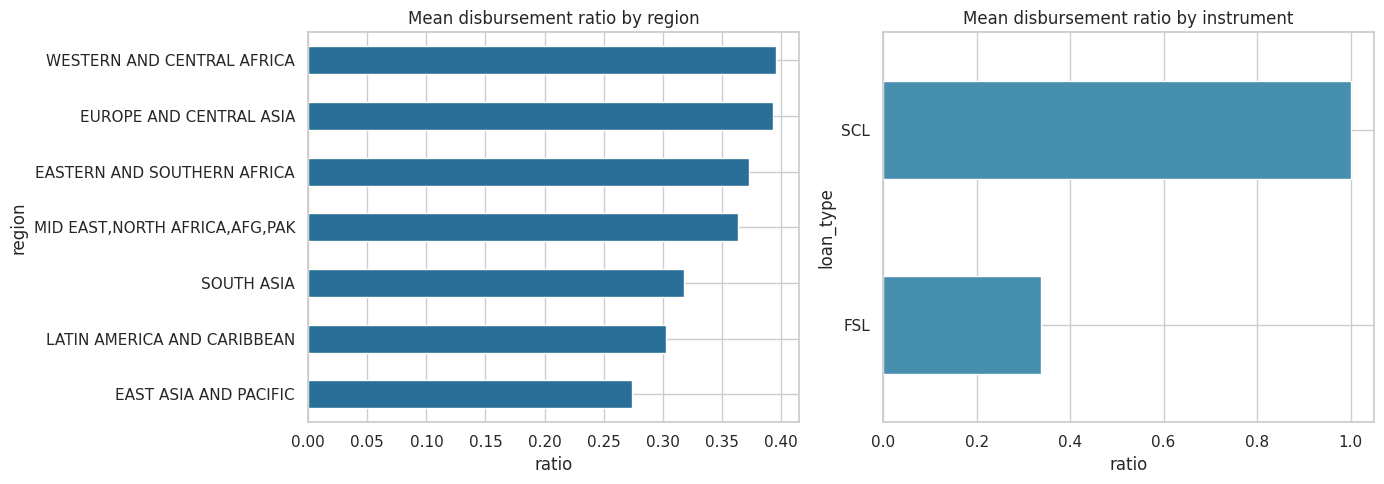

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
(df.groupby("region")["disbursement_ratio"].mean().sort_values()
   .plot.barh(ax=ax[0], color="#2a6f97"))
ax[0].set_title("Mean disbursement ratio by region"); ax[0].set_xlabel("ratio")

(df.groupby("loan_type")["disbursement_ratio"].mean().sort_values()
   .plot.barh(ax=ax[1], color="#468faf"))
ax[1].set_title("Mean disbursement ratio by instrument"); ax[1].set_xlabel("ratio")
plt.tight_layout(); plt.show()

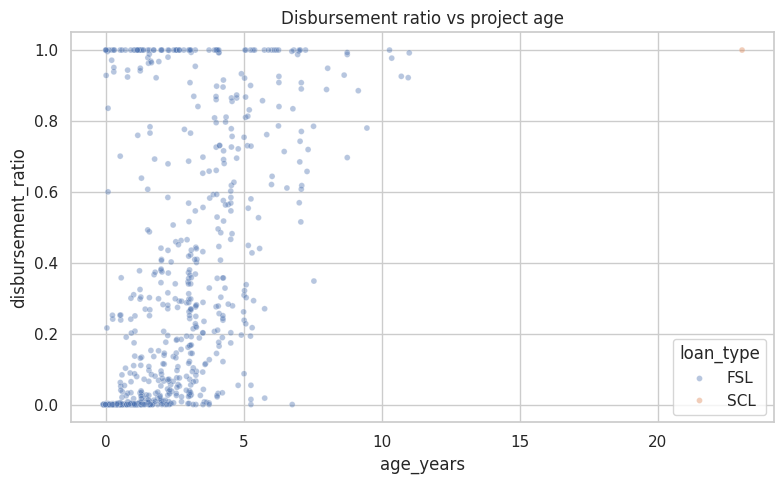

In [88]:
# disbursement pace vs age — the shape of the portfolio
plt.figure(figsize=(8,5))
sns.scatterplot(data=df.sample(min(2000,len(df)), random_state=321),
                x="age_years", y="disbursement_ratio",
                hue="loan_type", alpha=.4, s=18)
plt.title("Disbursement ratio vs project age"); plt.tight_layout(); plt.show()

## 4 · Target definition — "slow disburser"
A project is flagged **slow** when its disbursement ratio lags the pace its elapsed life
implies by more than 25 percentage points (`disbursement_gap > 0.25`). This is a
management-style rule, not an arbitrary label: it captures projects that are *behind schedule
on paying out*, controlling for how new they are.

In [89]:
df["slow_disburser"] = (df["disbursement_gap"] > 0.25).astype(int)

model_df = df.dropna(subset=["age_years","effectiveness_lag_days","planned_life_years",
                             "elapsed_share","net_commitment"]).copy()
print(f"modelling rows: {len(model_df):,}")
print(f"slow-disburser rate: {model_df['slow_disburser'].mean():.1%}")

modelling rows: 613
slow-disburser rate: 36.5%


In [90]:
# ===== Tableau extract: active disbursement-phase portfolio =====
tab = df.copy()
tab["commitment_musd"]   = tab["net_commitment"] / 1e6
tab["undisbursed_musd"]  = tab["undisbursed_amount"] / 1e6
tab["approval_year"]     = tab["board_approval_date"].dt.year
tab["status_flag"]       = tab["slow_disburser"].map({1: "Behind schedule", 0: "On track"})

cols = ["project_id","country","region","loan_type","loan_status","approval_year",
        "commitment_musd","undisbursed_musd","disbursement_ratio","undisbursed_ratio",
        "age_years","effectiveness_lag_days","disbursement_gap","status_flag"]
tab[cols].to_csv("disbursement_portfolio_tableau.csv", index=False)
print("saved:", tab.shape[0], "loans ->", "disbursement_portfolio_tableau.csv")

saved: 672 loans -> disbursement_portfolio_tableau.csv


## 5 · Evaluation helpers
Reusable metric functions with raw + normalised confusion matrices side by side.

In [91]:
def classification_metrics(y_true, y_pred, y_proba=None):
    m = {"accuracy":  accuracy_score(y_true, y_pred),
         "precision": precision_score(y_true, y_pred, zero_division=0),
         "recall":    recall_score(y_true, y_pred, zero_division=0),
         "f1":        f1_score(y_true, y_pred, zero_division=0)}
    if y_proba is not None:
        m["roc_auc"] = roc_auc_score(y_true, y_proba)
    return m

def evaluate_classification(model, X_tr, y_tr, X_te, y_te, labels=("on-track","slow")):
    results = {}
    for split, Xs, ys in [("train", X_tr, y_tr), ("test", X_te, y_te)]:
        pred  = model.predict(Xs)
        proba = model.predict_proba(Xs)[:, 1] if hasattr(model, "predict_proba") else None
        results[split] = classification_metrics(ys, pred, proba)
    # confusion matrices on the test split
    pred = model.predict(X_te)
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=labels).plot(
        ax=ax[0], colorbar=False); ax[0].set_title("Test — counts")
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred, normalize="true"),
        display_labels=labels).plot(ax=ax[1], colorbar=False, values_format=".2f")
    ax[1].set_title("Test — normalised"); plt.tight_layout(); plt.show()
    return pd.DataFrame(results).T.round(3)

## 6 · Split, scale, balance

In [92]:
num_features = ["net_commitment", "age_years", "effectiveness_lag_days", "planned_life_years"]
cat_features = ["region", "loan_type"]

X = pd.get_dummies(model_df[num_features + cat_features], columns=cat_features, drop_first=True)
y = model_df["slow_disburser"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=321, stratify=y)

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

print("class balance (train):", y_train.value_counts(normalize=True).round(3).to_dict())
if y_train.value_counts(normalize=True).min() < 0.40:
    X_train, y_train = SMOTE(random_state=321).fit_resample(X_train, y_train)
    print("after SMOTE:        ", y_train.value_counts().to_dict())

class balance (train): {0: 0.634, 1: 0.366}
after SMOTE:         {0: 291, 1: 291}


## 7 · Baseline model (timed)

LogisticRegression fit in 0.197s


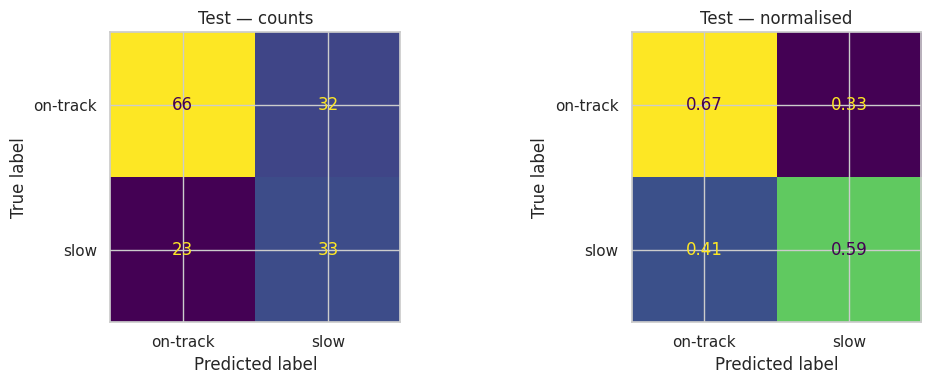

,accuracy,precision,recall,f1,roc_auc
train,0.63,0.65,0.57,0.61,0.72
test,0.64,0.51,0.59,0.55,0.76


In [93]:
t0 = dt.datetime.now()
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
dur_baseline = (dt.datetime.now() - t0).total_seconds()
print(f"LogisticRegression fit in {dur_baseline:.3f}s")
evaluate_classification(logreg, X_train, y_train, X_test, y_test)

## 8 · PCA experiments
Does compressing the feature space keep the signal while cutting fit time?

In [94]:
# first pass: 3 components
pca3 = PCA(n_components=3, random_state=321).fit(X_train)
print("explained variance (3 comps):", pca3.explained_variance_ratio_.round(3),
      "-> cumulative", pca3.explained_variance_ratio_.sum().round(3))

explained variance (3 comps): [0.388 0.184 0.171] -> cumulative 0.742


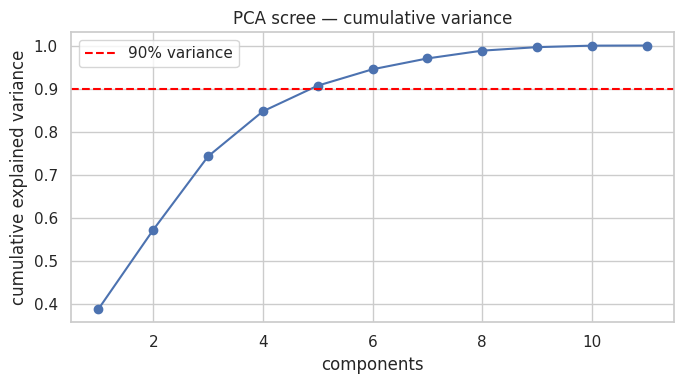

In [95]:
# how many components to reach 90% variance?
pca_full = PCA(random_state=321).fit(X_train)
cum = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum)+1), cum, marker="o")
plt.axhline(.9, ls="--", color="red", label="90% variance")
plt.xlabel("components"); plt.ylabel("cumulative explained variance")
plt.legend(); plt.title("PCA scree — cumulative variance"); plt.tight_layout(); plt.show()

components kept for 85% variance: 5
baseline fit: 0.197s   |   PCA fit: 0.022s


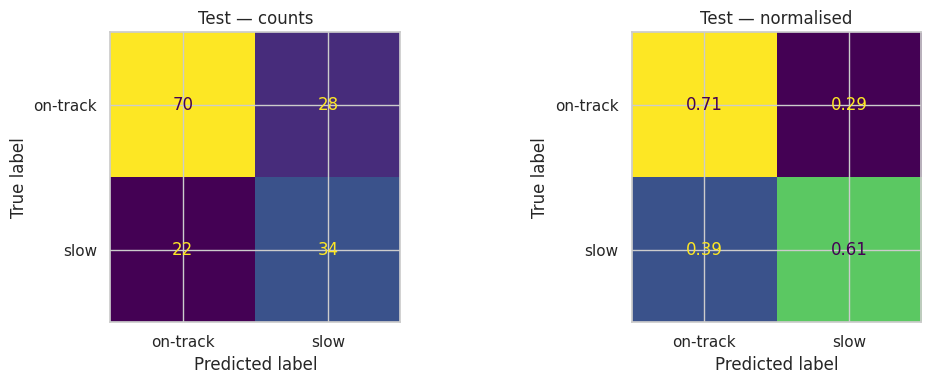

,accuracy,precision,recall,f1,roc_auc
train,0.63,0.66,0.56,0.60,0.71
test,0.68,0.55,0.61,0.58,0.76


In [96]:
# retain 85% of variance and time a model on the compressed space
pca = PCA(n_components=0.85, random_state=321)
X_train_p = pca.fit_transform(X_train)
X_test_p  = pca.transform(X_test)
print(f"components kept for 85% variance: {pca.n_components_}")

t0 = dt.datetime.now()
logreg_pca = LogisticRegression(max_iter=1000).fit(X_train_p, y_train)
dur_pca = (dt.datetime.now() - t0).total_seconds()
print(f"baseline fit: {dur_baseline:.3f}s   |   PCA fit: {dur_pca:.3f}s")
evaluate_classification(logreg_pca, X_train_p, y_train, X_test_p, y_test)

## 9 · Model comparison & drivers
Random Forest for non-linear interactions — but watch the train/test gap (overfitting).
The interpretable logistic model is usually the one you can defend to a portfolio committee.

RandomForest fit in 2.189s


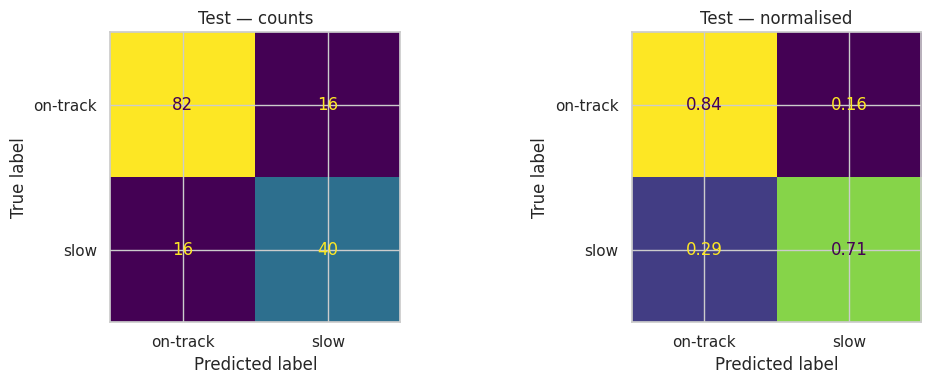

,accuracy,precision,recall,f1,roc_auc
train,1.00,1.00,1.00,1.00,1.00
test,0.79,0.71,0.71,0.71,0.87


In [97]:
t0 = dt.datetime.now()
rf = RandomForestClassifier(n_estimators=300, random_state=321, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"RandomForest fit in {(dt.datetime.now()-t0).total_seconds():.3f}s")
evaluate_classification(rf, X_train, y_train, X_test, y_test)

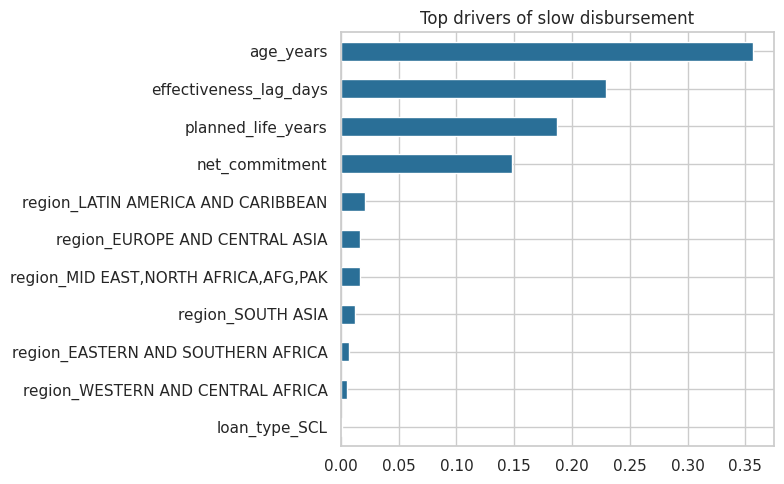

,0
age_years,0.36
effectiveness_lag_days,0.23
planned_life_years,0.19
net_commitment,0.15
region_LATIN AMERICA AND CARIBBEAN,0.02
region_EUROPE AND CENTRAL ASIA,0.02
"region_MID EAST,NORTH AFRICA,AFG,PAK",0.02
region_SOUTH ASIA,0.01
region_EASTERN AND SOUTHERN AFRICA,0.01
region_WESTERN AND CENTRAL AFRICA,0.01


In [98]:
# what drives the 'slow disburser' flag?
importances = (pd.Series(rf.feature_importances_, index=X_train.columns)
                 .sort_values(ascending=False).head(12))
plt.figure(figsize=(8,5))
importances.sort_values().plot.barh(color="#2a6f97")
plt.title("Top drivers of slow disbursement"); plt.tight_layout(); plt.show()
importances

## 10 · Findings & next steps

*Real IBRD Statement of Loans snapshot (as of 31 Jul 2026, 9,513 loans).*

### Population
Of 9,513 loans, only **672 are in the active disbursement phase** (Disbursing, Effective,
Signed, Approved). The rest have finished disbursing (Fully Disbursed, Repaying, Fully Repaid)
or are closed (Cancelled/Terminated) — none carry a live "speed of disbursement" question.
Restricting to the active phase is what makes the analysis meaningful (see methodology note).

### Headline
**38.7% of active IBRD loans are behind their implied disbursement pace** — nearly 4 in 10.
That is the share whose disbursement ratio lags the fraction of planned project life already
elapsed by more than 25 percentage points.

### Early-warning signal
The strongest *actionable* driver is a long **approval → effectiveness lag**
(`effectiveness_lag_days`, importance ≈ 0.23 — second only to loan age). Loans slow to become
effective are slow to disburse. This matches World Bank portfolio experience and mirrors the
disbursement-readiness logic applied at project level in a PCU.

### Model story
| Model | Test ROC-AUC | Precision | Recall | Train ROC-AUC |
|---|---|---|---|---|
| Logistic Regression | **0.75** | 0.56 | 0.65 | 0.73 |
| Random Forest | 0.88 | 0.75 | 0.70 | **1.00** |

Random Forest scores higher on test but memorises the training set perfectly
(train AUC = 1.00) — classic overfitting on a small sample. The logistic model shows a healthy
train/test gap and stays explainable to a portfolio committee, so **0.75 is the number to
trust**. The deliberate high-recall tuning (SMOTE) suits an early-warning use case: better to
flag a healthy loan for review than to miss a stalling one.

### Methodology note (why the numbers matter)
An earlier run that kept *Repaying* loans in the population produced an inflated AUC of ~0.90
and let loan **age** dominate (importance 0.53) — the model was mostly separating old,
already-repaid loans from young ones. Tightening the population to the genuinely
disbursement-phase portfolio dropped AUC to a truthful **0.75**, cut age's importance to 0.35,
and let the meaningful effectiveness-lag signal surface. *The more honest number was the more
useful one.*

### Caveats
- Small active sample (~613 modelled rows); the model is **illustrative, not production-grade**.
- "Slow disburser" is a management-style heuristic (gap > 25pp), not an official WB classification.
- Scope is **IBRD only** (middle-income borrowers; China and the Philippines feature heavily).

### Next steps
- **Tableau Public dashboard**: disbursement ratio by region, effectiveness-lag vs
  disbursement-gap scatter, undisbursed-balance treemap by country, slow-loan counts by
  approval vintage. *https://public.tableau.com/app/profile/tarteel.abu.ghazaleh/viz/IBRDDisbursement/IBRDDisbursementPerformanceAnalytics?publish=yes*
- Add the **IDA Statement of Credits & Grants** to extend coverage to the poorest countries
  and grant financing.

---
**What sets this project apart:** the same disbursement-ratio and withdrawal logic used on a
single project inside a PCU, applied — with a defensible population definition and an honest
model — across the entire IBRD portfolio.

*Data: World Bank Group Finances, IBRD Statement of Loans (CC-BY 4.0). Independent analysis, not endorsed by the World Bank.*